**Building Trustworthy Insights with BERT:**

In [1]:
# Install required libraries
!pip install -q transformers datasets accelerate scikit-learn matplotlib

In [2]:
# Imports

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModel,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import accuracy_score, f1_score
from collections import Counter

In [3]:
# 1. Data Loading & Inspection

dataset = load_dataset("tweet_eval", "sentiment")

print(dataset)

label_names = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

for split in dataset.keys():
    labels = dataset[split]["label"]
    counts = Counter(labels)

    print(f"\n{split} class distribution:")
    for label_id, count in counts.items():
        print(label_id, label_names[label_id], count)

print("\nNumber of labels:", len(set(dataset["train"]["label"])))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

train class distribution:
2 positive 17849
1 neutral 20673
0 negative 7093

test class distribution:
1 neutral 5937
2 positive 2375
0 negative 3972

validation class distribution:
1 neutral 869
2 positive 819
0 negative 312

Number of labels: 3


In [4]:
# Save two example tweets per label for later visualization

examples_by_label = {}

for label_id, label_name in label_names.items():
    examples = [
        row["text"]
        for row in dataset["train"]
        if row["label"] == label_id
    ][:2]

    examples_by_label[label_name] = examples

examples_by_label

{'negative': ['So disappointed in wwe summerslam! I want to see john cena wins his 16th title',
  'That sucks if you have to take the SATs tomorrow'],
 'neutral': ['"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"',
  'Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.'],
 'positive': ['"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"',
  '@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"']}

In [5]:
# 2. Tokenization Pipeline

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )
    tokens["labels"] = batch["label"]
    return tokens

tokenized_dataset = dataset.map(preprocess_function, batched=True)

tokenized_dataset = tokenized_dataset.shuffle(seed=42)

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

tokenized_dataset

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2000
    })
})

In [6]:
# 3. Fine-Tuning Setup

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
# Training configuration

output_dir = "./distilbert_tweet_eval_sentiment"

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=2,

    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [8]:
# Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.605557,0.624055,0.722500,0.708087
2,0.480110,0.630757,0.747500,0.727825
3,0.259502,0.807121,0.726500,0.709680


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4278, training_loss=0.4667891555436586, metrics={'train_runtime': 1541.3066, 'train_samples_per_second': 88.785, 'train_steps_per_second': 2.776, 'total_flos': 4531956111832320.0, 'train_loss': 0.4667891555436586, 'epoch': 3.0})

In [9]:
# Save the best model and tokenizer

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print("Model saved to:", output_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./distilbert_tweet_eval_sentiment


In [10]:
# 4. Evaluation & Calibration

validation_results = trainer.evaluate(tokenized_dataset["validation"])
validation_results

{'eval_loss': 0.6307590007781982,
 'eval_accuracy': 0.7475,
 'eval_macro_f1': 0.7278254800081229,
 'eval_runtime': 7.6256,
 'eval_samples_per_second': 262.275,
 'eval_steps_per_second': 8.262,
 'epoch': 3.0}

In [11]:
# Predict on the test split

test_predictions = trainer.predict(tokenized_dataset["test"])

test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids

test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
predicted_labels = np.argmax(test_probs, axis=1)
confidence_scores = np.max(test_probs, axis=1)

test_accuracy = accuracy_score(test_labels, predicted_labels)
test_macro_f1 = f1_score(test_labels, predicted_labels, average="macro")

print("Test accuracy:", test_accuracy)
print("Test macro F1:", test_macro_f1)

Test accuracy: 0.6830022793878215
Test macro F1: 0.6829959289715358


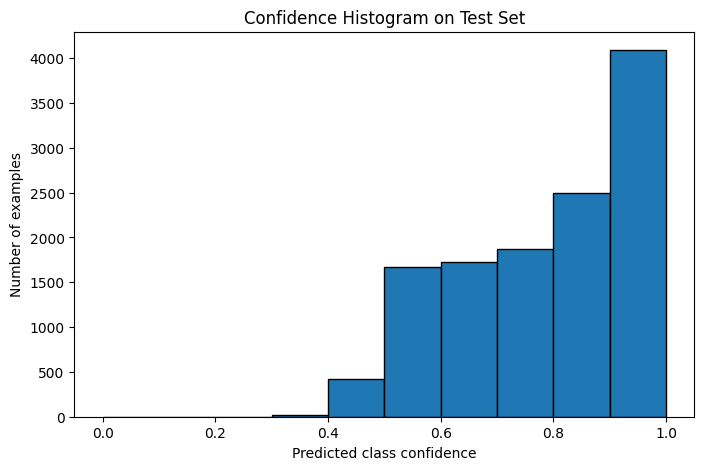

In [12]:
# Confidence histogram

plt.figure(figsize=(8, 5))
plt.hist(confidence_scores, bins=np.arange(0, 1.1, 0.1), edgecolor="black")
plt.xlabel("Predicted class confidence")
plt.ylabel("Number of examples")
plt.title("Confidence Histogram on Test Set")
plt.show()

The histogram shows how confident the model is in its predictions.
If most predictions are close to 1.0, the model may be overconfident, especially if the test accuracy is not equally high.
If many predictions are around 0.4-0.6, the model is uncertain and may need more training data, better preprocessing or calibration.

In [13]:
# 5. Attention Inspection

chosen_text = examples_by_label["negative"][0]

print("Chosen tweet:")
print(chosen_text)

Chosen tweet:
So disappointed in wwe summerslam! I want to see john cena wins his 16th title


In [14]:
# Load the fine-tuned encoder with attentions enabled

attention_model = AutoModel.from_pretrained(
    output_dir,
    output_attentions=True
)

attention_model.eval()

inputs = tokenizer(
    chosen_text,
    return_tensors="pt",
    truncation=True,
    padding="max_length",
    max_length=128
)

with torch.no_grad():
    outputs = attention_model(**inputs)

attentions = outputs.attentions

last_layer_attention = attentions[-1]

average_attention = last_layer_attention.mean(dim=1)

cls_attention = average_attention[0, 0, :]

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

attention_mask = inputs["attention_mask"][0].numpy()
valid_tokens = []
valid_scores = []

for token, score, mask in zip(tokens, cls_attention.numpy(), attention_mask):
    if mask == 1:
        valid_tokens.append(token)
        valid_scores.append(score)

attention_df = pd.DataFrame({
    "token": valid_tokens,
    "attention_score": valid_scores
})

attention_df

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: ./distilbert_tweet_eval_sentiment
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,token,attention_score
0,[CLS],0.007625
1,so,0.088737
2,disappointed,0.346329
3,in,0.030626
4,wwe,0.007868
5,summers,0.001703
6,##lam,0.011119
7,!,0.106584
8,i,0.077403
9,want,0.062442


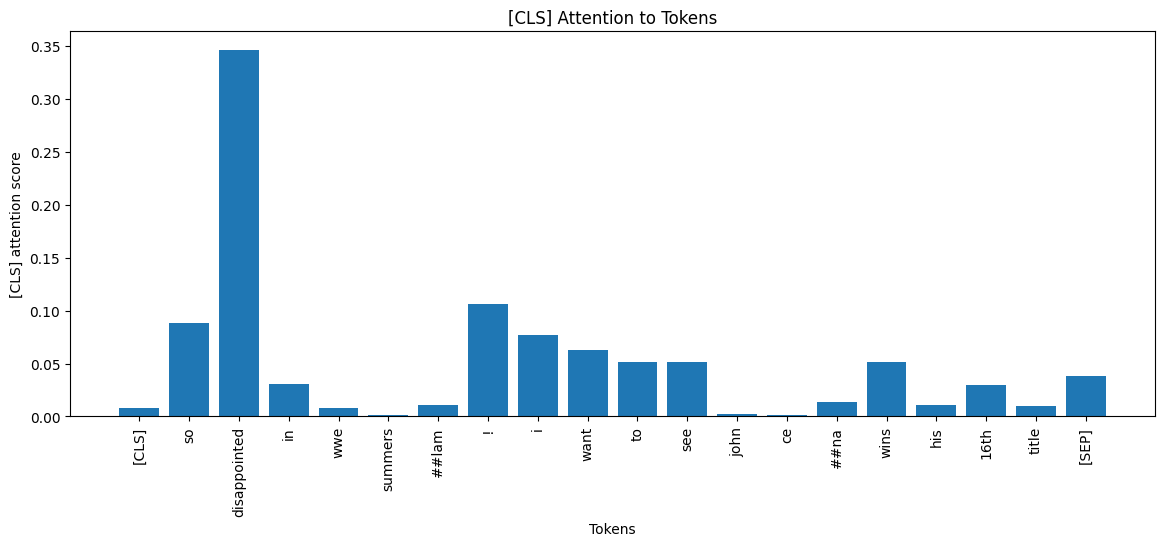

In [15]:
# Visualize CLS attention to tokens

plt.figure(figsize=(14, 5))
plt.bar(attention_df["token"], attention_df["attention_score"])
plt.xticks(rotation=90)
plt.xlabel("Tokens")
plt.ylabel("[CLS] attention score")
plt.title("[CLS] Attention to Tokens")
plt.show()

In [16]:
# Top attended tokens

top_tokens = attention_df.sort_values(
    by="attention_score",
    ascending=False
).head(10)

top_tokens

,token,attention_score
2,disappointed,0.346329
7,!,0.106584
1,so,0.088737
8,i,0.077403
9,want,0.062442
15,wins,0.051622
10,to,0.051365
11,see,0.051119
19,[SEP],0.038388
3,in,0.030626


The attention visualization shows which tokens received the strongest attention from the [CLS] token in the last transformer layer.
These tokens can be interpreted as possible evidence used by the model when forming the sentence-level representation.
However, attention is not a perfect explanation of decision. It is useful as an inspection tool, but it should not be treated as full proof of causality.

In [17]:
# 6. Explainable Inference Helper

classifier = AutoModelForSequenceClassification.from_pretrained(output_dir)
classifier.eval()

encoder = AutoModel.from_pretrained(output_dir, output_attentions=True)
encoder.eval()

def analyze_text(text, top_k=5):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    )

    with torch.no_grad():
        classifier_outputs = classifier(**inputs)
        logits = classifier_outputs.logits
        probs = torch.softmax(logits, dim=1)

        predicted_id = torch.argmax(probs, dim=1).item()
        confidence = probs[0, predicted_id].item()

        encoder_outputs = encoder(**inputs)
        attentions = encoder_outputs.attentions

    last_layer_attention = attentions[-1]
    average_attention = last_layer_attention.mean(dim=1)
    cls_attention = average_attention[0, 0, :]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    attention_mask = inputs["attention_mask"][0].numpy()

    token_scores = []

    for token, score, mask in zip(tokens, cls_attention.numpy(), attention_mask):
        if mask == 1:
            if token not in ["[CLS]", "[SEP]", "[PAD]"]:
                token_scores.append((token, float(score)))

    token_scores = sorted(token_scores, key=lambda x: x[1], reverse=True)
    highlighted_tokens = token_scores[:top_k]

    return {
        "label": label_names[predicted_id],
        "confidence": round(confidence, 4),
        "highlighted_tokens": highlighted_tokens
    }

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: ./distilbert_tweet_eval_sentiment
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
# Test the helper

sample_text = "The service was terrible and I will never use this again."

result = analyze_text(sample_text)

result

{'label': 'negative',
 'confidence': 0.9735,
 'highlighted_tokens': [('never', 0.13893423974514008),
  ('will', 0.1226172149181366),
  ('i', 0.1094886064529419),
  ('this', 0.09898164123296738),
  ('and', 0.08509910851716995)]}

The analyze_text() function returns the predicted sentiment label, the model confidence and the tokens that received the strongest [CLS] attention.
This makes the model more transparent for a teammate or business user, because it gives both the decision and possible evidence tokens.

In [19]:
# Check saved artifacts

print("Saved files:")
for file in os.listdir(output_dir):
    print(file)

Saved files:
training_args.bin
checkpoint-4278
config.json
checkpoint-2852
tokenizer.json
tokenizer_config.json
model.safetensors
